In [1]:
# ============================================================
# CAPSTONE PROJECT - PART 2
# VERSION 3
# CELL 1 - LOAD DATASET & DEFINE TARGETS
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# Create Output Directory
# ------------------------------------------------------------

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("CAPSTONE PROJECT")
print("PART 2 - SUPERVISED MACHINE LEARNING")
print("CELL 1 - DATA LOADING")
print("="*90)

# ------------------------------------------------------------
# Load Clean Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

print("\nDataset Loaded Successfully")
print("-"*90)

print("Shape :", df.shape)

print("\nFirst Five Rows")

display(df.head())

print("\nColumn Names")

print(df.columns.tolist())

# ------------------------------------------------------------
# Define Regression Target
# ------------------------------------------------------------

y_reg = df["glucose"]

print("\nRegression Target")

print("Target Column :", y_reg.name)

# ------------------------------------------------------------
# Define Classification Target
# ------------------------------------------------------------

# OPTION 1:
# If label column is already binary use it.

if df["label"].nunique() == 2:

    y_clf = df["label"]

    classification_type = "Existing Binary Label"

# OPTION 2:
# Otherwise create binary target using glucose median.

else:

    y_clf = (df["glucose"] > df["glucose"].median()).astype(int)

    classification_type = "Median-based Binary Label"

print("\nClassification Target")

print(classification_type)

print("\nClass Distribution")

print(y_clf.value_counts())

# ------------------------------------------------------------
# Feature Matrix
# ------------------------------------------------------------

X = df.drop(columns=["glucose"])

# remove label also if it exists

if "label" in X.columns:

    X = X.drop(columns=["label"])

print("\nFeature Matrix")

print("Shape :", X.shape)

print("\nTarget Summary")

summary = pd.DataFrame({

    "Regression Target":[y_reg.name],

    "Classification Target":[classification_type],

    "Feature Count":[X.shape[1]],

    "Rows":[X.shape[0]]

})

display(summary)

summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "dataset_summary.csv"

    ),

    index=False

)

print("="*90)
print("CELL 1 COMPLETED")
print("="*90)

CAPSTONE PROJECT
PART 2 - SUPERVISED MACHINE LEARNING
CELL 1 - DATA LOADING

Dataset Loaded Successfully
------------------------------------------------------------------------------------------
Shape : (278701, 39)

First Five Rows


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal



Column Names
['composite_key', 'age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel', 'label']

Regression Target
Target Column : glucose

Classification Target
Existing Binary Label

Class Distribution
label
Abnormal    174053
Normal      104648
Name: count, dtype: int64

Feature Matrix
Shape : (278701, 37)

Target Summary


,Regression Target,Classification Target,Feature Count,Rows
0,glucose,Existing Binary Label,37,278701


CELL 1 COMPLETED


In [2]:
# ============================================================
# CAPSTONE PROJECT - PART 2
# VERSION 3
# CELL 2 - CATEGORICAL ENCODING
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("PART 2 - CELL 2")
print("CATEGORICAL FEATURE ENCODING")
print("="*90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

print("\nDataset Shape :", df.shape)

# ------------------------------------------------------------
# Ordinal Encoding
# ------------------------------------------------------------

ordinal_mappings = {

    "age_level": {
        "Young":0,
        "Middle":1,
        "Old":2
    },

    "bmi_level": {
        "Underweight":0,
        "Normal":1,
        "Overweight":2,
        "Obese":3
    }

}

encoding_report = []

for column, mapping in ordinal_mappings.items():

    if column in df.columns:

        print(f"\nLabel Encoding : {column}")

        df[column] = df[column].map(mapping)

        encoding_report.append({

            "Column":column,

            "Encoding":"Label Encoding",

            "Reason":"Ordinal Feature"

        })

# ------------------------------------------------------------
# One Hot Encoding
# ------------------------------------------------------------

exclude_columns = [

    "label",
    "glucose"

]

categorical_columns = [

    col for col in df.select_dtypes(include="object").columns

    if col not in exclude_columns

]

print("\nNominal Columns")

print(categorical_columns)

df = pd.get_dummies(

    df,

    columns=categorical_columns,

    drop_first=True,

    dtype=int

)

for col in categorical_columns:

    encoding_report.append({

        "Column":col,

        "Encoding":"One-Hot Encoding",

        "Reason":"Nominal Feature"

    })

# ------------------------------------------------------------
# Save Reports
# ------------------------------------------------------------

encoding_df = pd.DataFrame(encoding_report)

encoding_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "encoding_report.csv"

    ),

    index=False

)

df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "encoded_dataset.csv"

    ),

    index=False

)

print("\nEncoded Dataset Shape")

print(df.shape)

print("\nFirst Five Rows")

display(df.head())

print("\nEncoding Report")

display(encoding_df)

print("="*90)
print("CELL 2 COMPLETED")
print("="*90)

PART 2 - CELL 2
CATEGORICAL FEATURE ENCODING

Dataset Shape : (278701, 39)

Label Encoding : age_level

Label Encoding : bmi_level

Nominal Columns
['composite_key', 'gender', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel']


C:\Users\chell\AppData\Local\Temp\ipykernel_15888\1335583643.py:81: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include="object").columns



Encoded Dataset Shape
(278701, 248)

First Five Rows


,age_level,bmi_level,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,...,"disease_flags_1,0,1","disease_flags_1,1,0","disease_flags_1,1,1",sublabel_DI_HT,sublabel_DI_HT_HY,sublabel_DI_HY,sublabel_HT,sublabel_HT_HY,sublabel_HY,sublabel_N
0,0.0,1,9,0.080460,19.20,0.0,0.0,5.8,158.0,214.703704,...,0,0,0,0,0,0,0,0,0,1
1,0.0,1,3,0.011494,22.55,0.0,0.0,6.6,159.0,214.703704,...,0,0,0,0,0,0,0,0,0,1
2,0.0,1,3,0.011494,22.89,0.0,0.0,4.0,126.0,214.703704,...,0,0,0,0,0,0,0,0,0,1
3,0.0,1,3,0.011494,23.12,0.0,0.0,6.2,85.0,214.703704,...,0,0,0,0,0,0,0,0,0,1
4,0.0,1,4,0.022989,19.61,0.0,0.0,5.7,155.0,214.703704,...,0,0,0,0,0,0,0,0,0,1



Encoding Report


,Column,Encoding,Reason
0,age_level,Label Encoding,Ordinal Feature
1,bmi_level,Label Encoding,Ordinal Feature
2,composite_key,One-Hot Encoding,Nominal Feature
3,gender,One-Hot Encoding,Nominal Feature
4,smoking,One-Hot Encoding,Nominal Feature
5,diabetes,One-Hot Encoding,Nominal Feature
6,physical_activity,One-Hot Encoding,Nominal Feature
7,family_history,One-Hot Encoding,Nominal Feature
8,stress_level,One-Hot Encoding,Nominal Feature
9,low_hdl_cholesterol,One-Hot Encoding,Nominal Feature


CELL 2 COMPLETED


In [3]:
# ============================================================
# CAPSTONE PROJECT - PART 2
# VERSION 3
# CELL 3 - TRAIN TEST SPLIT & FEATURE SCALING
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 90)
print("PART 2 - CELL 3")
print("TRAIN TEST SPLIT & STANDARD SCALER")
print("=" * 90)

# ------------------------------------------------------------
# Load Encoded Dataset
# ------------------------------------------------------------

df = pd.read_csv(os.path.join(OUTPUT_DIR, "encoded_dataset.csv"))

print("\nDataset Shape :", df.shape)

# ------------------------------------------------------------
# Define Targets
# ------------------------------------------------------------

y_reg = df["glucose"]

if "label" in df.columns and df["label"].nunique() == 2:
    y_clf = df["label"]
else:
    y_clf = (df["glucose"] > df["glucose"].median()).astype(int)

X = df.drop(columns=["glucose"])

if "label" in X.columns:
    X = X.drop(columns=["label"])

# ------------------------------------------------------------
# Train-Test Split (Regression)
# ------------------------------------------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Train-Test Split (Classification)
# ------------------------------------------------------------

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

# ------------------------------------------------------------
# StandardScaler (Regression)
# ------------------------------------------------------------

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# ------------------------------------------------------------
# StandardScaler (Classification)
# ------------------------------------------------------------

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# ------------------------------------------------------------
# Save Scalers
# ------------------------------------------------------------

joblib.dump(
    scaler_reg,
    os.path.join(OUTPUT_DIR, "regression_scaler.pkl")
)

joblib.dump(
    scaler_clf,
    os.path.join(OUTPUT_DIR, "classification_scaler.pkl")
)

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Dataset":[
        "Regression Train",
        "Regression Test",
        "Classification Train",
        "Classification Test"
    ],

    "Rows":[
        X_train_reg.shape[0],
        X_test_reg.shape[0],
        X_train_clf.shape[0],
        X_test_clf.shape[0]
    ],

    "Columns":[
        X_train_reg.shape[1],
        X_test_reg.shape[1],
        X_train_clf.shape[1],
        X_test_clf.shape[1]
    ]

})

display(summary)

summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_test_summary.csv"
    ),
    index=False
)

print("\nScaling Completed Successfully")

print("\nRegression Train Shape :", X_train_reg_scaled.shape)
print("Regression Test Shape  :", X_test_reg_scaled.shape)

print("\nClassification Train Shape :", X_train_clf_scaled.shape)
print("Classification Test Shape  :", X_test_clf_scaled.shape)

print("=" * 90)
print("CELL 3 COMPLETED")
print("=" * 90)

PART 2 - CELL 3
TRAIN TEST SPLIT & STANDARD SCALER

Dataset Shape : (278701, 248)


,Dataset,Rows,Columns
0,Regression Train,222960,246
1,Regression Test,55741,246
2,Classification Train,222960,246
3,Classification Test,55741,246



Scaling Completed Successfully

Regression Train Shape : (222960, 246)
Regression Test Shape  : (55741, 246)

Classification Train Shape : (222960, 246)
Classification Test Shape  : (55741, 246)
CELL 3 COMPLETED


In [4]:
# ============================================================
# PART 2 - VERSION 3.1
# CELL 4
# LINEAR REGRESSION
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

OUTPUT_DIR = "output"

print("=" * 90)
print("PART 2 - CELL 4")
print("LINEAR REGRESSION")
print("=" * 90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv(os.path.join(OUTPUT_DIR, "encoded_dataset.csv"))

print("Dataset Shape :", df.shape)

# ------------------------------------------------------------
# Regression Target
# ------------------------------------------------------------

TARGET = "glucose"

# ------------------------------------------------------------
# Remove columns that shouldn't be predictors
# ------------------------------------------------------------

drop_columns = [TARGET]

if "label" in df.columns:
    drop_columns.append("label")

X = df.drop(columns=drop_columns).copy()

y = df[TARGET].copy()

# ------------------------------------------------------------
# Keep only numeric columns
# ------------------------------------------------------------

X = X.select_dtypes(include=np.number)

print("Number of Features :", X.shape[1])

# ------------------------------------------------------------
# Train Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Missing Value Imputation
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns
)

print("\nRemaining Missing Values")

print("Train :", X_train.isnull().sum().sum())

print("Test  :", X_test.isnull().sum().sum())

# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")

print(f"MSE : {mse:.4f}")

print(f"R²  : {r2:.4f}")

# ------------------------------------------------------------
# Coefficients
# ------------------------------------------------------------

coef_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(

    by="Absolute",

    ascending=False

)

print("\nTop 10 Important Features")

print(coef_df.head(10))

# ------------------------------------------------------------
# Save Outputs
# ------------------------------------------------------------

coef_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "linear_regression_coefficients.csv"

    ),

    index=False

)

metrics = pd.DataFrame({

    "Metric": ["MSE", "R2"],

    "Value": [mse, r2]

})

metrics.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "linear_regression_metrics.csv"

    ),

    index=False

)

print("\nCell 4 Completed Successfully")

PART 2 - CELL 4
LINEAR REGRESSION
Dataset Shape : (278701, 248)
Number of Features : 246

Remaining Missing Values
Train : 0
Test  : 0

Model Performance
MSE : 1428.8113
R²  : 0.0355

Top 10 Important Features
                         Feature  Coefficient  Absolute
231  source_dataset_hypertension    -5.714033  5.714033
230         source_dataset_heart    -5.416163  5.416163
245                   sublabel_N    -2.201306  2.201306
6                  heart_disease    -2.077410  2.077410
235          disease_flags_1,0,0     1.897457  1.897457
215                 diabetes_Yes     1.529463  1.529463
239               sublabel_DI_HT     1.247739  1.247739
237          disease_flags_1,1,0     1.247739  1.247739
4                            bmi     1.155037  1.155037
222     high_ldl_cholesterol_Yes     1.066828  1.066828

Cell 4 Completed Successfully


In [5]:
# ============================================================
# PART 2 - VERSION 3.1
# CELL 5
# RIDGE REGRESSION
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

OUTPUT_DIR = "output"

print("=" * 90)
print("PART 2 - CELL 5")
print("RIDGE REGRESSION")
print("=" * 90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv(os.path.join(OUTPUT_DIR, "encoded_dataset.csv"))

TARGET = "glucose"

drop_columns = [TARGET]

if "label" in df.columns:
    drop_columns.append("label")

X = df.drop(columns=drop_columns).copy()

y = df[TARGET].copy()

# ------------------------------------------------------------
# Numeric Features
# ------------------------------------------------------------

X = X.select_dtypes(include=np.number)

print("Dataset Shape :", X.shape)

# ------------------------------------------------------------
# Train Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Missing Value Imputation
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns
)

print("Remaining Missing Values")

print("Train :", X_train.isnull().sum().sum())

print("Test  :", X_test.isnull().sum().sum())

# ------------------------------------------------------------
# Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Ridge Regression
# ------------------------------------------------------------

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = ridge.predict(X_test_scaled)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nRIDGE PERFORMANCE")

print(f"MSE : {mse:.4f}")

print(f"R²  : {r2:.4f}")

# ------------------------------------------------------------
# Coefficients
# ------------------------------------------------------------

coef_df = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": ridge.coef_

})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(

    by="Absolute",

    ascending=False

)

print("\nTop 10 Ridge Features")

print(coef_df.head(10))

coef_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "ridge_coefficients.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Save Metrics
# ------------------------------------------------------------

ridge_metrics = pd.DataFrame({

    "Metric": ["MSE","R2"],

    "Value": [mse,r2]

})

ridge_metrics.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "ridge_metrics.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Compare with Linear Regression
# ------------------------------------------------------------

linear_metrics = pd.read_csv(

    os.path.join(

        OUTPUT_DIR,

        "linear_regression_metrics.csv"

    )

)

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "MSE":[
        linear_metrics.loc[0,"Value"],
        mse
    ],

    "R2":[
        linear_metrics.loc[1,"Value"],
        r2
    ]

})

comparison.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "ridge_vs_linear.csv"

    ),

    index=False

)

print("\nComparison")

print(comparison)

print("\nCell 5 Completed Successfully.")

PART 2 - CELL 5
RIDGE REGRESSION
Dataset Shape : (278701, 246)
Remaining Missing Values
Train : 0
Test  : 0

RIDGE PERFORMANCE
MSE : 1428.8113
R²  : 0.0355

Top 10 Ridge Features
                         Feature  Coefficient  Absolute
231  source_dataset_hypertension    -5.713936  5.713936
230         source_dataset_heart    -5.416098  5.416098
245                   sublabel_N    -2.201292  2.201292
6                  heart_disease    -2.077337  2.077337
235          disease_flags_1,0,0     1.897470  1.897470
215                 diabetes_Yes     1.529476  1.529476
239               sublabel_DI_HT     1.247730  1.247730
237          disease_flags_1,1,0     1.247730  1.247730
4                            bmi     1.154999  1.154999
222     high_ldl_cholesterol_Yes     1.066809  1.066809

Comparison
               Model          MSE        R2
0  Linear Regression  1428.811289  0.035542
1   Ridge Regression  1428.811281  0.035542

Cell 5 Completed Successfully.


In [6]:
# ============================================================
# Cell 6A - Logistic Regression Training (Version 3.1)
# Part 1/2
#
# Includes:
# - Dataset loading
# - Train/Test split
# - Missing value handling
# - Numerical scaling
# - Categorical encoding
# - Data leakage prevention
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ==========================
# 2. Create Output Folder
# ==========================

OUTPUT_DIR = "output"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Output folder created:", OUTPUT_DIR)



# ==========================
# 3. Load Dataset
# ==========================

DATA_PATH = "cleaned_data.csv"

df = pd.read_csv(DATA_PATH)


print("Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


display(df.head())



# ==========================
# 4. Define Target Column
# ==========================

TARGET_COLUMN = "diabetes"


if TARGET_COLUMN not in df.columns:

    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found. "
        "Please check your dataset column name."
    )



# ==========================
# 5. Separate Features and Target
# ==========================


X = df.drop(
    TARGET_COLUMN,
    axis=1
)


y = df[TARGET_COLUMN]



print("\nFeature Shape:")
print(X.shape)


print("\nTarget Distribution:")
print(y.value_counts())



# ==========================
# 6. Train Test Split
# ==========================


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



print("\nTraining Data Shape:")
print(X_train.shape)


print("\nTesting Data Shape:")
print(X_test.shape)



# ==========================
# 7. Identify Feature Types
# ==========================


numeric_features = X_train.select_dtypes(

    include=[
        "int64",
        "float64"
    ]

).columns



categorical_features = X_train.select_dtypes(

    include=[
        "object",
        "category"
    ]

).columns



print("\nNumber of Numerical Features:")
print(len(numeric_features))


print("\nNumber of Categorical Features:")
print(len(categorical_features))



# ==========================
# 8. Numerical Preprocessing
# ==========================


numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(

                strategy="median"

            )

        ),


        (
            "scaler",

            StandardScaler()

        )

    ]

)



# ==========================
# 9. Categorical Preprocessing
# ==========================


categorical_pipeline = Pipeline(

    steps=[


        (
            "imputer",

            SimpleImputer(

                strategy="most_frequent"

            )

        ),



        (
            "encoder",

            OneHotEncoder(

                handle_unknown="ignore"

            )

        )


    ]

)



# ==========================
# 10. Combine Preprocessing
# ==========================


preprocessor = ColumnTransformer(

    transformers=[


        (
            "numeric",

            numeric_pipeline,

            numeric_features

        ),



        (
            "categorical",

            categorical_pipeline,

            categorical_features

        )

    ]

)



print("\nPreprocessing Pipeline Created Successfully")

# ============================================================
# Cell 6A - Logistic Regression Training (Version 3.1)
# Part 2/2
#
# Includes:
# - Model creation
# - Training
# - Evaluation
# - Saving files
# ============================================================


# ==========================
# 11. Create Logistic Regression Model
# ==========================


logistic_model = LogisticRegression(

    max_iter=1000,

    class_weight="balanced",

    random_state=42,

    solver="liblinear"

)



# ==========================
# 12. Create Complete Pipeline
# ==========================


model_pipeline = Pipeline(

    steps=[


        (
            "preprocessor",

            preprocessor

        ),



        (
            "classifier",

            logistic_model

        )

    ]

)



print("\nLogistic Regression Pipeline Created")



# ==========================
# 13. Train Model
# ==========================


print("\nTraining Logistic Regression Model...")



model_pipeline.fit(

    X_train,

    y_train

)



print("\nModel Training Completed Successfully")



# ==========================
# 14. Predictions
# ==========================


y_pred = model_pipeline.predict(

    X_test

)



y_probability = model_pipeline.predict_proba(

    X_test

)[:,1]



print("\nPrediction Completed")


# ==========================
# 15. Model Evaluation
# ==========================


accuracy = accuracy_score(

    y_test,

    y_pred

)


precision = precision_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)


recall = recall_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)


f1 = f1_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)



results = pd.DataFrame(

    {

        "Metric":

        [

            "Accuracy",

            "Precision",

            "Recall",

            "F1 Score"

        ],


        "Score":

        [

            accuracy,

            precision,

            recall,

            f1

        ]

    }

)



print("\nModel Performance:")

display(results)



# ==========================
# 16. Classification Report
# ==========================


print("\nClassification Report:")


print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0

    )

)



# ==========================
# 17. Confusion Matrix
# ==========================


cm = confusion_matrix(

    y_test,

    y_pred

)


print("\nConfusion Matrix:")

print(cm)



# ==========================
# 18. Save Training Results
# ==========================


results_path = os.path.join(

    OUTPUT_DIR,

    "logistic_training_results.csv"

)


results.to_csv(

    results_path,

    index=False

)



print(

    "\nSaved:",

    results_path

)



# ==========================
# 19. Save Predictions
# ==========================


prediction_df = pd.DataFrame(

    {

        "Actual": y_test.values,

        "Predicted": y_pred,

        "Probability_Yes": y_probability

    }

)



prediction_path = os.path.join(

    OUTPUT_DIR,

    "logistic_predictions.csv"

)



prediction_df.to_csv(

    prediction_path,

    index=False

)



print(

    "Saved:",

    prediction_path

)



# ==========================
# 20. Save Model Pipeline
# ==========================


model_path = os.path.join(

    OUTPUT_DIR,

    "logistic_regression_pipeline.pkl"

)



joblib.dump(

    model_pipeline,

    model_path

)



print(

    "Saved:",

    model_path

)



print("\n====================================")

print("CELL 6A COMPLETED SUCCESSFULLY")

print("====================================")

Output folder created: output
Dataset Loaded Successfully

Dataset Shape:
(278701, 39)


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal



Feature Shape:
(278701, 38)

Target Distribution:
diabetes
No     178083
Yes    100618
Name: count, dtype: int64

Training Data Shape:
(222960, 38)

Testing Data Shape:
(55741, 38)

Number of Numerical Features:
20

Number of Categorical Features:
18

Preprocessing Pipeline Created Successfully

Logistic Regression Pipeline Created

Training Logistic Regression Model...

Model Training Completed Successfully

Prediction Completed

Model Performance:


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0



Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00     35617
         Yes       1.00      1.00      1.00     20124

    accuracy                           1.00     55741
   macro avg       1.00      1.00      1.00     55741
weighted avg       1.00      1.00      1.00     55741


Confusion Matrix:
[[35617     0]
 [    0 20124]]

Saved: output\logistic_training_results.csv
Saved: output\logistic_predictions.csv
Saved: output\logistic_regression_pipeline.pkl

CELL 6A COMPLETED SUCCESSFULLY


Output folder: output
Model loaded successfully


,Actual,Predicted,Probability_Yes
0,No,No,0.000049
1,Yes,Yes,0.999948
2,Yes,Yes,0.999965
3,Yes,Yes,0.999970
4,No,No,0.000124



Evaluation Results


,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0



Classification Report
              precision    recall  f1-score   support

          No       1.00      1.00      1.00     35617
         Yes       1.00      1.00      1.00     20124

    accuracy                           1.00     55741
   macro avg       1.00      1.00      1.00     55741
weighted avg       1.00      1.00      1.00     55741


Confusion Matrix
[[35617     0]
 [    0 20124]]

ROC-AUC Score: 1.0


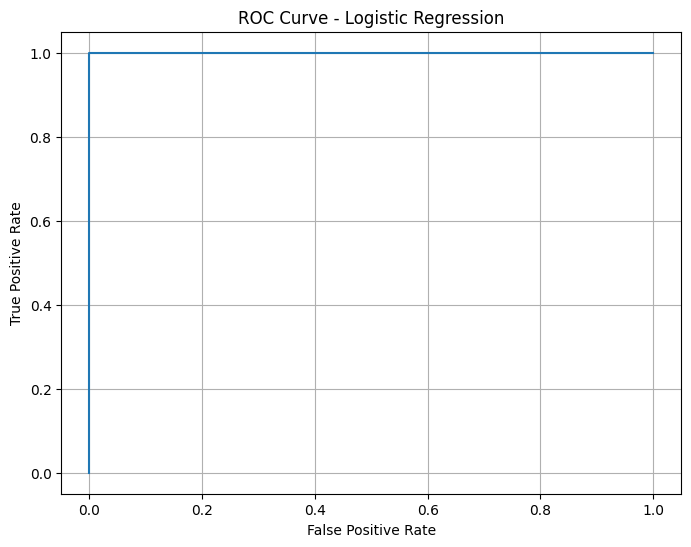


CELL 6B COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# Cell 6B - Logistic Regression Evaluation (Version 3.1)
#
# Purpose:
# - Load trained model
# - Evaluate model performance
# - Generate reports
# - Save evaluation outputs
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os

import pandas as pd
import numpy as np

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt



# ==========================
# 2. Output Folder
# ==========================


OUTPUT_DIR = "output"


print(
    "Output folder:",
    OUTPUT_DIR
)



# ==========================
# 3. Load Saved Model
# ==========================


MODEL_PATH = os.path.join(

    OUTPUT_DIR,

    "logistic_regression_pipeline.pkl"

)


model = joblib.load(

    MODEL_PATH

)


print(
    "Model loaded successfully"
)



# ==========================
# 4. Load Test Predictions
# ==========================


prediction_file = os.path.join(

    OUTPUT_DIR,

    "logistic_predictions.csv"

)


prediction_df = pd.read_csv(

    prediction_file

)



display(prediction_df.head())



# ==========================
# 5. Separate Values
# ==========================


y_test = prediction_df["Actual"]


y_pred = prediction_df["Predicted"]


y_probability = prediction_df["Probability_Yes"]



# ==========================
# 6. Calculate Metrics
# ==========================


accuracy = accuracy_score(

    y_test,

    y_pred

)


precision = precision_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)


recall = recall_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)


f1 = f1_score(

    y_test,

    y_pred,

    pos_label="Yes",

    zero_division=0

)



evaluation_results = pd.DataFrame(

    {

        "Metric":

        [

            "Accuracy",

            "Precision",

            "Recall",

            "F1 Score"

        ],


        "Score":

        [

            accuracy,

            precision,

            recall,

            f1

        ]

    }

)



print("\nEvaluation Results")

display(evaluation_results)



# ==========================
# 7. Classification Report
# ==========================


print("\nClassification Report")


report = classification_report(

    y_test,

    y_pred

)


print(report)



# Save report

with open(

    os.path.join(

        OUTPUT_DIR,

        "classification_report.txt"

    ),

    "w"

) as file:

    file.write(report)



# ==========================
# 8. Confusion Matrix
# ==========================


cm = confusion_matrix(

    y_test,

    y_pred

)


print("\nConfusion Matrix")

print(cm)



cm_df = pd.DataFrame(

    cm,

    index=[
        "Actual_No",
        "Actual_Yes"
    ],

    columns=[
        "Predicted_No",
        "Predicted_Yes"
    ]

)


cm_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "confusion_matrix.csv"

    )

)



# ==========================
# 9. ROC-AUC Score
# ==========================


y_test_binary = y_test.map(

    {

        "No":0,

        "Yes":1

    }

)



auc_score = roc_auc_score(

    y_test_binary,

    y_probability

)


print(

    "\nROC-AUC Score:",

    auc_score

)



# Save AUC score

with open(

    os.path.join(

        OUTPUT_DIR,

        "auc_score.txt"

    ),

    "w"

) as file:

    file.write(

        str(auc_score)

    )



# ==========================
# 10. ROC Curve
# ==========================


fpr, tpr, thresholds = roc_curve(

    y_test_binary,

    y_probability

)


plt.figure(

    figsize=(8,6)

)


plt.plot(

    fpr,

    tpr

)


plt.xlabel(

    "False Positive Rate"

)


plt.ylabel(

    "True Positive Rate"

)


plt.title(

    "ROC Curve - Logistic Regression"

)


plt.grid()


plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "roc_curve.png"

    ),

    bbox_inches="tight"

)


plt.show()



# ==========================
# 11. Save Evaluation Results
# ==========================


evaluation_results.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "logistic_evaluation_results.csv"

    ),

    index=False

)



print("\n===================================")

print("CELL 6B COMPLETED SUCCESSFULLY")

print("===================================")

Output folder: output


,Actual,Predicted,Probability_Yes
0,No,No,0.000049
1,Yes,Yes,0.999948
2,Yes,Yes,0.999965
3,Yes,Yes,0.999970
4,No,No,0.000124



Target Classes:
Actual
No     35617
Yes    20124
Name: count, dtype: int64


,Threshold,Accuracy,Precision,Recall,F1_Score
0,0.1,1.0,1.0,1.0,1.0
1,0.2,1.0,1.0,1.0,1.0
2,0.3,1.0,1.0,1.0,1.0
3,0.4,1.0,1.0,1.0,1.0
4,0.5,1.0,1.0,1.0,1.0
5,0.6,1.0,1.0,1.0,1.0
6,0.7,1.0,1.0,1.0,1.0
7,0.8,1.0,1.0,1.0,1.0
8,0.9,1.0,1.0,1.0,1.0



Best Threshold:
0.1

Best F1 Score:
1.0

Saved: output\threshold_analysis.csv


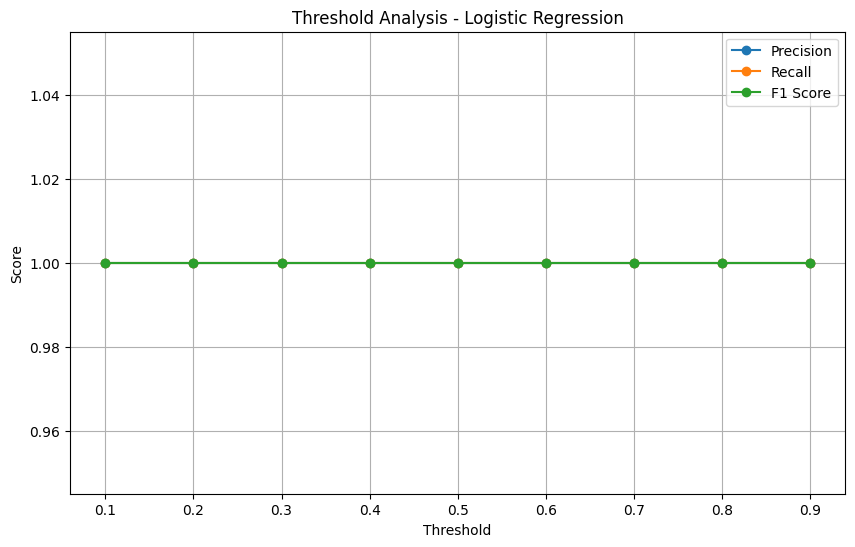


CELL 7 COMPLETED SUCCESSFULLY


In [8]:
# ============================================================
# Cell 7 - Threshold Analysis (Version 3.1)
#
# Purpose:
# - Test different classification thresholds
# - Compare model performance
# - Find best threshold based on F1 Score
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt



# ==========================
# 2. Output Folder
# ==========================

OUTPUT_DIR = "output"


print(
    "Output folder:",
    OUTPUT_DIR
)



# ==========================
# 3. Load Prediction Results
# ==========================


prediction_path = os.path.join(

    OUTPUT_DIR,

    "logistic_predictions.csv"

)


prediction_df = pd.read_csv(

    prediction_path

)



display(prediction_df.head())



# ==========================
# 4. Prepare Data
# ==========================


y_true = prediction_df["Actual"]


probability = prediction_df["Probability_Yes"]



print("\nTarget Classes:")

print(

    y_true.value_counts()

)



# Convert actual values

y_true_binary = y_true.map(

    {

        "No":0,

        "Yes":1

    }

)



# ==========================
# 5. Define Thresholds
# ==========================


thresholds = [

    0.10,

    0.20,

    0.30,

    0.40,

    0.50,

    0.60,

    0.70,

    0.80,

    0.90

]



# Store results

threshold_results = []



# ==========================
# 6. Evaluate Each Threshold
# ==========================


for threshold in thresholds:


    # Convert probability to prediction

    y_pred_binary = (

        probability >= threshold

    ).astype(int)



    accuracy = accuracy_score(

        y_true_binary,

        y_pred_binary

    )


    precision = precision_score(

        y_true_binary,

        y_pred_binary,

        zero_division=0

    )


    recall = recall_score(

        y_true_binary,

        y_pred_binary,

        zero_division=0

    )


    f1 = f1_score(

        y_true_binary,

        y_pred_binary,

        zero_division=0

    )



    threshold_results.append(

        {

            "Threshold": threshold,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1_Score": f1

        }

    )



# ==========================
# 7. Create Results DataFrame
# ==========================


threshold_df = pd.DataFrame(

    threshold_results

)



display(

    threshold_df

)



# ==========================
# 8. Find Best Threshold
# ==========================


best_row = threshold_df.loc[

    threshold_df["F1_Score"].idxmax()

]


best_threshold = best_row["Threshold"]


best_f1 = best_row["F1_Score"]



print("\nBest Threshold:")

print(best_threshold)


print("\nBest F1 Score:")

print(best_f1)



# ==========================
# 9. Save Results
# ==========================


threshold_csv = os.path.join(

    OUTPUT_DIR,

    "threshold_analysis.csv"

)


threshold_df.to_csv(

    threshold_csv,

    index=False

)



print(

    "\nSaved:",

    threshold_csv

)



# ==========================
# 10. Save Best Threshold
# ==========================


with open(

    os.path.join(

        OUTPUT_DIR,

        "best_threshold.txt"

    ),

    "w"

) as file:


    file.write(

        f"Best Threshold: {best_threshold}\n"

    )

    file.write(

        f"Best F1 Score: {best_f1}"

    )



# ==========================
# 11. Plot Threshold Performance
# ==========================


plt.figure(

    figsize=(10,6)

)


plt.plot(

    threshold_df["Threshold"],

    threshold_df["Precision"],

    marker="o",

    label="Precision"

)



plt.plot(

    threshold_df["Threshold"],

    threshold_df["Recall"],

    marker="o",

    label="Recall"

)



plt.plot(

    threshold_df["Threshold"],

    threshold_df["F1_Score"],

    marker="o",

    label="F1 Score"

)



plt.xlabel(

    "Threshold"

)


plt.ylabel(

    "Score"

)


plt.title(

    "Threshold Analysis - Logistic Regression"

)


plt.legend()


plt.grid()



plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "threshold_analysis.png"

    ),

    bbox_inches="tight"

)



plt.show()



print("\n===================================")

print("CELL 7 COMPLETED SUCCESSFULLY")

print("===================================")

Output folder: output


,Actual,Predicted,Probability_Yes
0,No,No,0.000049
1,Yes,Yes,0.999948
2,Yes,Yes,0.999965
3,Yes,Yes,0.999970
4,No,No,0.000124



Actual Target Distribution:
Actual
No     35617
Yes    20124
Name: count, dtype: int64

ROC-AUC Score: 1.0


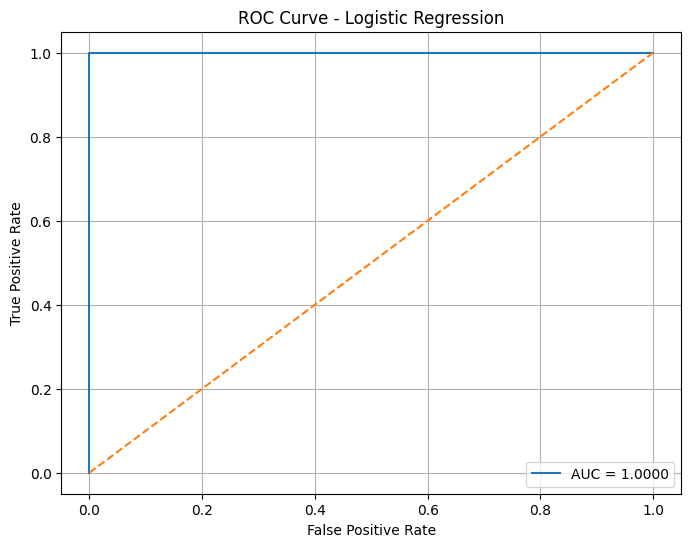


ROC Curve Saved: output\ROC_AUC_Curve.png
Report Saved: output\ROC_AUC_Report.txt

CELL 8 COMPLETED SUCCESSFULLY


In [9]:
# ============================================================
# Cell 8 - ROC Curve & AUC Analysis (Version 3.1)
#
# Purpose:
# - Calculate ROC-AUC score
# - Generate ROC curve
# - Save AUC report
# - Evaluate classifier performance
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)



# ==========================
# 2. Output Folder
# ==========================

OUTPUT_DIR = "output"


print(
    "Output folder:",
    OUTPUT_DIR
)



# ==========================
# 3. Load Prediction Data
# ==========================


prediction_path = os.path.join(

    OUTPUT_DIR,

    "logistic_predictions.csv"

)


prediction_df = pd.read_csv(

    prediction_path

)



display(

    prediction_df.head()

)



# ==========================
# 4. Prepare Data
# ==========================


y_actual = prediction_df["Actual"]


y_probability = prediction_df["Probability_Yes"]



print("\nActual Target Distribution:")

print(

    y_actual.value_counts()

)



# Convert target

y_binary = y_actual.map(

    {

        "No":0,

        "Yes":1

    }

)



# ==========================
# 5. Calculate AUC Score
# ==========================


auc_score = roc_auc_score(

    y_binary,

    y_probability

)



print(

    "\nROC-AUC Score:",

    auc_score

)



# ==========================
# 6. Generate ROC Curve
# ==========================


fpr, tpr, thresholds = roc_curve(

    y_binary,

    y_probability

)



# ==========================
# 7. Plot ROC Curve
# ==========================


plt.figure(

    figsize=(8,6)

)



plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc_score:.4f}"

)



# Random classifier line

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)



plt.xlabel(

    "False Positive Rate"

)



plt.ylabel(

    "True Positive Rate"

)



plt.title(

    "ROC Curve - Logistic Regression"

)



plt.legend()



plt.grid()



roc_path = os.path.join(

    OUTPUT_DIR,

    "ROC_AUC_Curve.png"

)



plt.savefig(

    roc_path,

    bbox_inches="tight"

)



plt.show()



print(

    "\nROC Curve Saved:",

    roc_path

)



# ==========================
# 8. Save AUC Report
# ==========================


report_path = os.path.join(

    OUTPUT_DIR,

    "ROC_AUC_Report.txt"

)



with open(

    report_path,

    "w"

) as file:


    file.write(

        "ROC-AUC Evaluation Report\n"

    )

    file.write(

        "========================\n\n"

    )

    file.write(

        f"Model: Logistic Regression\n\n"

    )

    file.write(

        f"AUC Score: {auc_score:.4f}\n\n"

    )


    if auc_score >= 0.90:

        interpretation = "Excellent classifier performance"


    elif auc_score >= 0.80:

        interpretation = "Good classifier performance"


    elif auc_score >= 0.70:

        interpretation = "Acceptable classifier performance"


    elif auc_score >= 0.60:

        interpretation = "Weak classifier performance"


    else:

        interpretation = "Poor classifier performance"



    file.write(

        "Interpretation: "

        + interpretation

    )



print(

    "Report Saved:",

    report_path

)



print("\n===================================")

print("CELL 8 COMPLETED SUCCESSFULLY")

print("===================================")

In [10]:
# ============================================================
# Cell 9 - Regularization Comparison (Version 3.1)
#
# Purpose:
# - Compare Logistic Regression with different C values
# - Analyze effect of regularization
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)



# ==========================
# 2. Output Folder
# ==========================

OUTPUT_DIR = "output"


print(
    "Output folder:",
    OUTPUT_DIR
)



# ==========================
# 3. Load Dataset
# ==========================

DATA_PATH = "cleaned_data.csv"


df = pd.read_csv(

    DATA_PATH

)



print(

    "Dataset Shape:",

    df.shape

)



# ==========================
# 4. Separate Features and Target
# ==========================


TARGET_COLUMN = "diabetes"



X = df.drop(

    TARGET_COLUMN,

    axis=1

)



y = df[TARGET_COLUMN]



# Convert target

y_binary = y.map(

    {

        "No":0,

        "Yes":1

    }

)



# ==========================
# 5. Train Test Split
# ==========================


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_binary,

    test_size=0.2,

    random_state=42,

    stratify=y_binary

)



print(

    "Train Shape:",

    X_train.shape

)



print(

    "Test Shape:",

    X_test.shape

)



# ==========================
# 6. Feature Identification
# ==========================


numeric_features = X_train.select_dtypes(

    include=[

        "int64",

        "float64"

    ]

).columns



categorical_features = X_train.select_dtypes(

    include=[

        "object",

        "category"

    ]

).columns



# ==========================
# 7. Preprocessing Pipeline
# ==========================


numeric_pipeline = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(

                strategy="median"

            )

        ),


        (

            "scaler",

            StandardScaler()

        )

    ]

)



categorical_pipeline = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(

                strategy="most_frequent"

            )

        ),


        (

            "encoder",

            OneHotEncoder(

                handle_unknown="ignore"

            )

        )

    ]

)



preprocessor = ColumnTransformer(

    transformers=[

        (

            "numeric",

            numeric_pipeline,

            numeric_features

        ),


        (

            "categorical",

            categorical_pipeline,

            categorical_features

        )

    ]

)



# ==========================
# 8. Define Models
# ==========================


models = {


    "Logistic Regression C=1.0":

    LogisticRegression(

        C=1.0,

        max_iter=1000,

        class_weight="balanced",

        solver="liblinear",

        random_state=42

    ),



    "Logistic Regression C=0.01":

    LogisticRegression(

        C=0.01,

        max_iter=1000,

        class_weight="balanced",

        solver="liblinear",

        random_state=42

    )

}



# ==========================
# 9. Train and Compare
# ==========================


results = []



for model_name, model in models.items():


    print(

        "\nTraining:",

        model_name

    )



    pipeline = Pipeline(

        steps=[

            (

                "preprocessor",

                preprocessor

            ),


            (

                "classifier",

                model

            )

        ]

    )



    pipeline.fit(

        X_train,

        y_train

    )



    y_pred = pipeline.predict(

        X_test

    )



    y_prob = pipeline.predict_proba(

        X_test

    )[:,1]



    accuracy = accuracy_score(

        y_test,

        y_pred

    )



    precision = precision_score(

        y_test,

        y_pred,

        zero_division=0

    )



    recall = recall_score(

        y_test,

        y_pred,

        zero_division=0

    )



    f1 = f1_score(

        y_test,

        y_pred,

        zero_division=0

    )



    auc = roc_auc_score(

        y_test,

        y_prob

    )



    results.append(

        {

            "Model": model_name,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1 Score": f1,

            "ROC AUC": auc

        }

    )



# ==========================
# 10. Create Comparison Table
# ==========================


comparison_df = pd.DataFrame(

    results

)



display(

    comparison_df

)



# ==========================
# 11. Save Results
# ==========================


comparison_path = os.path.join(

    OUTPUT_DIR,

    "regularization_comparison.csv"

)



comparison_df.to_csv(

    comparison_path,

    index=False

)



print(

    "\nSaved:",

    comparison_path

)



# ==========================
# 12. Generate Report
# ==========================


best_model = comparison_df.loc[

    comparison_df["F1 Score"].idxmax()

]



report_path = os.path.join(

    OUTPUT_DIR,

    "regularization_comparison_report.txt"

)



with open(

    report_path,

    "w"

) as file:


    file.write(

        "Logistic Regression Regularization Comparison\n"

    )


    file.write(

        "=============================================\n\n"

    )


    file.write(

        comparison_df.to_string()

    )


    file.write(

        "\n\nBest Model Based on F1 Score:\n"

    )


    file.write(

        str(best_model)

    )



print(

    "Saved:",

    report_path

)



print("\n===================================")

print("CELL 9 COMPLETED SUCCESSFULLY")

print("===================================")

Output folder: output
Dataset Shape: (278701, 39)
Train Shape: (222960, 38)
Test Shape: (55741, 38)

Training: Logistic Regression C=1.0

Training: Logistic Regression C=0.01


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression C=1.0,1.000000,1.000000,1.0,1.000000,1.0
1,Logistic Regression C=0.01,0.999946,0.999851,1.0,0.999925,1.0



Saved: output\regularization_comparison.csv
Saved: output\regularization_comparison_report.txt

CELL 9 COMPLETED SUCCESSFULLY


In [11]:
# ============================================================
# Cell 10 - Bootstrap Confidence Interval Analysis (Version 3.1)
#
# Purpose:
# - Estimate model performance stability
# - Calculate bootstrap confidence interval
# ============================================================


# ==========================
# 1. Import Libraries
# ==========================

import os

import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score



# ==========================
# 2. Output Folder
# ==========================

OUTPUT_DIR = "output"


print(
    "Output folder:",
    OUTPUT_DIR
)



# ==========================
# 3. Load Predictions
# ==========================


prediction_path = os.path.join(

    OUTPUT_DIR,

    "logistic_predictions.csv"

)


prediction_df = pd.read_csv(

    prediction_path

)



display(

    prediction_df.head()

)



# ==========================
# 4. Prepare Data
# ==========================


y_actual = prediction_df["Actual"]


y_predicted = prediction_df["Predicted"]



print("\nDataset Size:")

print(

    len(y_actual)

)



# ==========================
# 5. Bootstrap Configuration
# ==========================


n_iterations = 1000


sample_size = len(y_actual)


random_seed = 42



np.random.seed(

    random_seed

)



bootstrap_scores = []



# ==========================
# 6. Bootstrap Sampling
# ==========================


print("\nRunning Bootstrap Sampling...")



for i in range(n_iterations):


    sample_indices = np.random.choice(

        np.arange(sample_size),

        size=sample_size,

        replace=True

    )



    actual_sample = y_actual.iloc[

        sample_indices

    ]



    predicted_sample = y_predicted.iloc[

        sample_indices

    ]



    accuracy = accuracy_score(

        actual_sample,

        predicted_sample

    )



    bootstrap_scores.append(

        accuracy

    )



print(

    "Bootstrap Completed"

)



# ==========================
# 7. Calculate Confidence Interval
# ==========================


mean_accuracy = np.mean(

    bootstrap_scores

)


lower_limit = np.percentile(

    bootstrap_scores,

    2.5

)


upper_limit = np.percentile(

    bootstrap_scores,

    97.5

)



print(

    "\nMean Accuracy:",

    mean_accuracy

)


print(

    "95% Confidence Interval:",

    lower_limit,

    "-",

    upper_limit

)



# ==========================
# 8. Save Bootstrap Results
# ==========================


bootstrap_df = pd.DataFrame(

    {

        "Bootstrap_Accuracy":

        bootstrap_scores

    }

)



bootstrap_csv_path = os.path.join(

    OUTPUT_DIR,

    "bootstrap_results.csv"

)



bootstrap_df.to_csv(

    bootstrap_csv_path,

    index=False

)



print(

    "\nSaved:",

    bootstrap_csv_path

)



# ==========================
# 9. Generate Report
# ==========================


report_path = os.path.join(

    OUTPUT_DIR,

    "bootstrap_report.txt"

)



with open(

    report_path,

    "w"

) as file:


    file.write(

        "Bootstrap Confidence Interval Report\n"

    )


    file.write(

        "===================================\n\n"

    )


    file.write(

        f"Bootstrap Iterations: {n_iterations}\n\n"

    )


    file.write(

        f"Mean Accuracy: {mean_accuracy:.4f}\n\n"

    )


    file.write(

        f"95% Confidence Interval:\n"

    )


    file.write(

        f"{lower_limit:.4f} - {upper_limit:.4f}\n"

    )



print(

    "Saved:",

    report_path

)



print("\n===================================")

print("CELL 10 COMPLETED SUCCESSFULLY")

print("===================================")

Output folder: output


,Actual,Predicted,Probability_Yes
0,No,No,0.000049
1,Yes,Yes,0.999948
2,Yes,Yes,0.999965
3,Yes,Yes,0.999970
4,No,No,0.000124



Dataset Size:
55741

Running Bootstrap Sampling...
Bootstrap Completed

Mean Accuracy: 1.0
95% Confidence Interval: 1.0 - 1.0

Saved: output\bootstrap_results.csv
Saved: output\bootstrap_report.txt

CELL 10 COMPLETED SUCCESSFULLY
